In [1]:
from sklearn import datasets

wdbc = datasets.load_breast_cancer()

X = wdbc.data
y = wdbc.target

print("Data shape  :", X.shape)
print("Target shape:", y.shape)
print("Target names:", wdbc.target_names)
print("First 5 feature names:", wdbc.feature_names[:5])

Data shape  : (569, 30)
Target shape: (569,)
Target names: ['malignant' 'benign']
First 5 feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


In [3]:
from sklearn import svm, tree, neighbors, ensemble
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#train model
svm_model = svm.SVC()
svm_model.fit(X_train, y_train)
predict = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, predict)
precision = precision_score(y_test, predict)
recall = recall_score(y_test, predict)

print("Default Classifier: SVM")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")



Default Classifier: SVM
Accuracy: 0.95
Precision: 0.92
Recall: 1.00


In [6]:
from sklearn import tree, neighbors, ensemble

models = {
    "SVM": svm.SVC(),
    "Decision Tree": tree.DecisionTreeClassifier(random_state=42),
    "KNN": neighbors.KNeighborsClassifier(),
    "Random Forest": ensemble.RandomForestClassifier(random_state=42),
}

accuracies = {}
precisions = {}
recalls = {}

for name, model in models.items():
  #train model
  model.fit(X_train, y_train)
  predict = model.predict(X_test)
  accuracy = accuracy_score(y_test, predict)
  precision = precision_score(y_test, predict)
  recall = recall_score(y_test, predict)
  accuracies[name] = accuracy
  precisions[name] = precision
  recalls[name] = recall

  print(f"{name} Accuracy: {accuracy:.2f}")
  print(f"{name} Precision: {precision:.2f}")
  print(f"{name} Recall: {recall:.2f}")
  print()

SVM Accuracy: 0.95
SVM Precision: 0.92
SVM Recall: 1.00

Decision Tree Accuracy: 0.95
Decision Tree Precision: 0.96
Decision Tree Recall: 0.96

KNN Accuracy: 0.96
KNN Precision: 0.93
KNN Recall: 1.00

Random Forest Accuracy: 0.96
Random Forest Precision: 0.96
Random Forest Recall: 0.99




Best Classifier: Random Forest


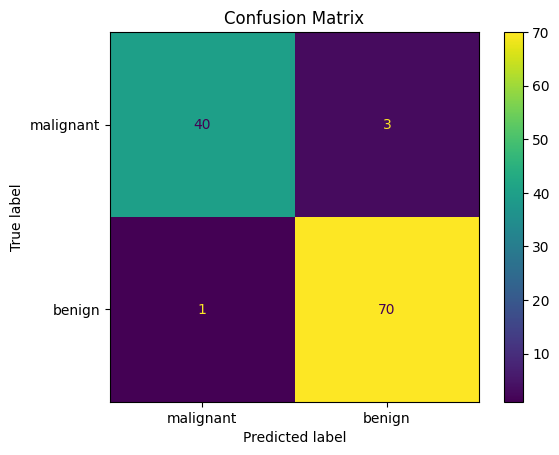

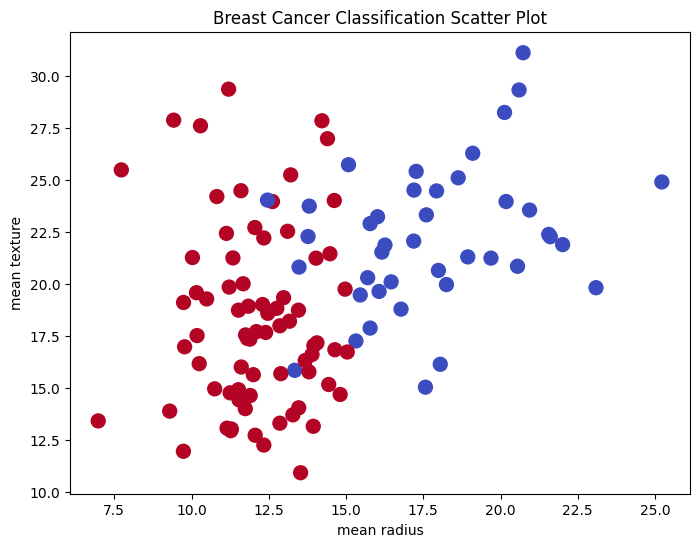

In [14]:
#best classifier

best_classifier = max(accuracies, key=accuracies.get)
print(f"\nBest Classifier: {best_classifier}")

#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predict)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=wdbc.target_names
)
disp.plot()
plt.title("Confusion Matrix")
plt.savefig("wdbc_classification_matrix.png")
plt.show()


#scatter plot

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=predict,
    cmap="coolwarm",
    s=100
)

plt.xlabel(wdbc.feature_names[0])
plt.ylabel(wdbc.feature_names[1])
plt.title("Breast Cancer Classification Scatter Plot")
plt.savefig("wdbc_classification_scatter.png")
plt.show()